In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation Library
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.model_selection import GridSearchCV

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
fashion_train=pd.read_csv("fashion-mnist_train.csv")
fashion_test=pd.read_csv("fashion-mnist_test.csv")

In [3]:
fashion_train.shape

(60000, 785)

In [4]:
fashion_test.shape

(10000, 785)

In [5]:
X_train_fashion=fashion_train.drop('label',axis=1)
y_train_fashion=fashion_train['label']
X_test_fashion=fashion_test.drop('label',axis=1)
y_test_fashion=fashion_test['label']

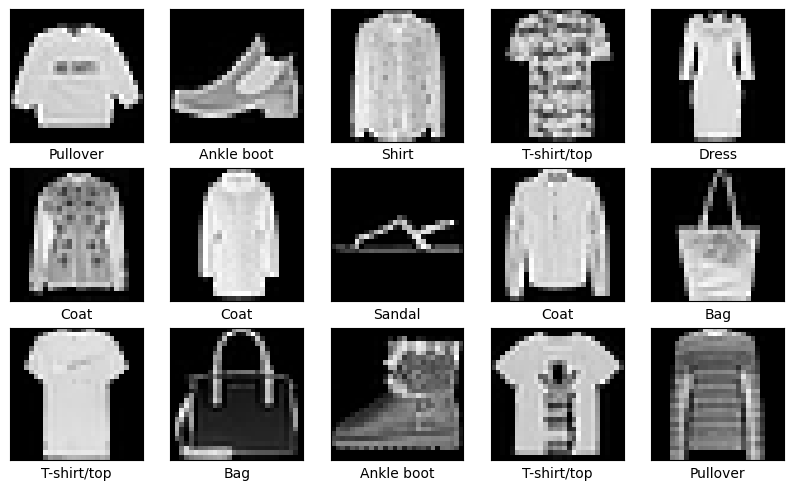

In [6]:
#Reshaping the dataset
X_train_reshape=X_train_fashion.values.reshape(-1,28,28)
X_test_reshape=X_test_fashion.values.reshape(-1,28,28)

#Names of clothing accessories in order
col_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i],cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [7]:
y_train_fashion=to_categorical(y_train_fashion,num_classes=10)
y_test_fashion=to_categorical(y_test_fashion,num_classes=10)

In [8]:
#Creating base neural network
model=keras.Sequential([
    layers.Dense(128,activation='relu',input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10,activation='softmax'),
])

C:\Anaconda3\envs\aiml_new\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [10]:
history=model.fit(X_train_fashion,y_train_fashion,batch_size=100,epochs=10,validation_data=(X_test_fashion,y_test_fashion))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6276 - loss: 1.0805 - val_accuracy: 0.8125 - val_loss: 0.5600
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7486 - loss: 0.7458 - val_accuracy: 0.8402 - val_loss: 0.4653
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7799 - loss: 0.6616 - val_accuracy: 0.8506 - val_loss: 0.4385
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7927 - loss: 0.6246 - val_accuracy: 0.8338 - val_loss: 0.4848
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7945 - loss: 0.6115 - val_accuracy: 0.8512 - val_loss: 0.4510
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8014 - loss: 0.5958 - val_accuracy: 0.8546 - val_loss: 0.4355
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8049 - loss: 0.5815 - val_accuracy: 0.8535 - val_loss: 0.4409
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8072 - loss: 0.5762 - val_

In [11]:
test_loss_fashion,test_acc_fashion=model.evaluate(X_test_fashion,y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8660 - loss: 0.4060


In [12]:
print("Fashion MNIST Test accuracy:", round(test_acc_fashion,4))

Fashion MNIST Test accuracy: 0.866


In [13]:
#Predicting the labels-Fashion
y_predict_fash=model.predict(X_test_fashion)
y_predicts_fash=np.argmax(y_predict_fash,axis=1)
y_test_fash_eval=np.argmax(y_test_fashion,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


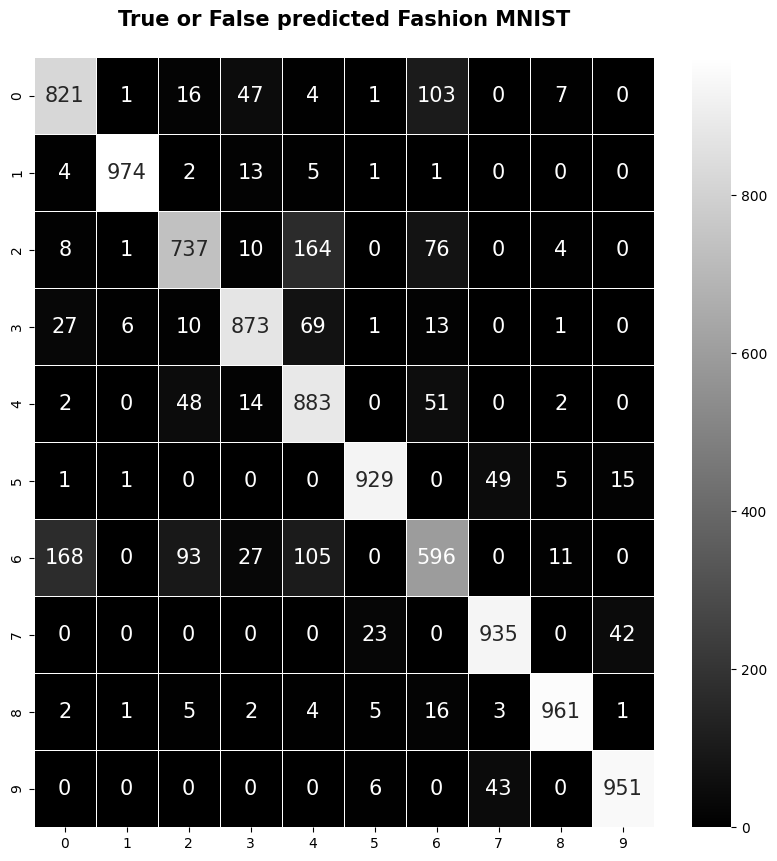

In [14]:
#Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_fash_eval,y_predicts_fash)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted Fashion MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [15]:
print(classification_report(y_test_fash_eval,y_predicts_fash))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.74      0.77      1000
           3       0.89      0.87      0.88      1000
           4       0.72      0.88      0.79      1000
           5       0.96      0.93      0.95      1000
           6       0.70      0.60      0.64      1000
           7       0.91      0.94      0.92      1000
           8       0.97      0.96      0.97      1000
           9       0.94      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [16]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


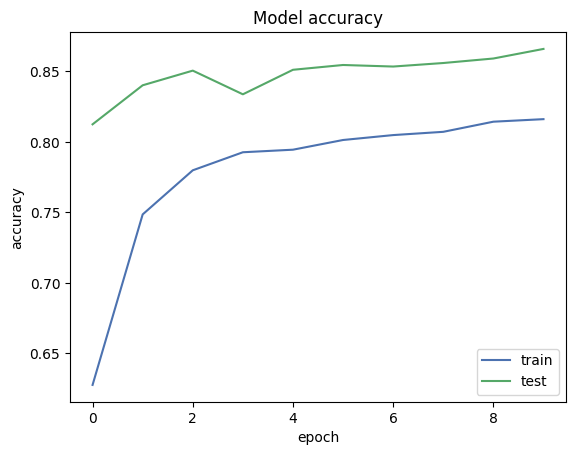

In [17]:
# summatize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

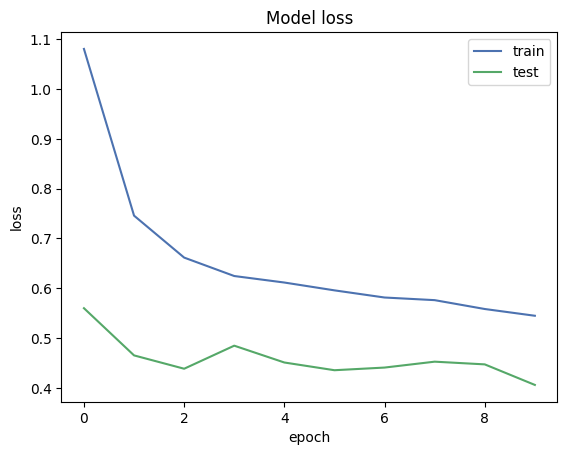

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

In [19]:
#tf.expand_dims(X_test_digit[0])
y_predict=model.predict(X_test_fashion.loc[[0],:].values)
y_predicts=np.argmax(y_predict,axis=1) #Here we get the index of maximum value in the encoded vector
y_test_fash_eval=np.argmax(y_test_fashion,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


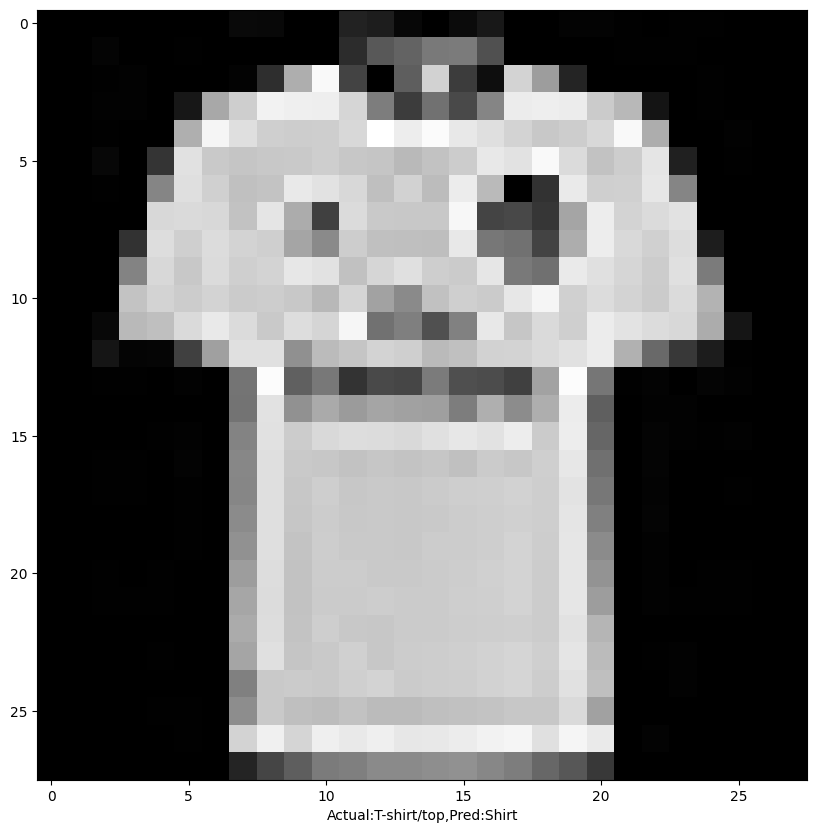

In [20]:
#Names of clothing accessories in order
col_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the images
plt.figure(figsize=(10,10))

plt.imshow(X_test_reshape[0],cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_fashion[0])],col_names[y_predicts[0]]))
plt.show()